In [1]:
%pip install ucimlrepo seaborn --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
# ============================================
# Instalación y carga de librerías
# ============================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from ucimlrepo import fetch_ucirepo

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

El dataset utilizado es Heart Disease del UCI Machine Learning Repository (id=45). Combina información de cuatro centros médicos distintos, aunque el subconjunto en el que trabajamos acá conta de 303 pacientes y 14 variables clínicas y demográficas seleccionadas de un total de 76 atributos originales.

Las variables incluyen datos demográficos (edad, sexo), mediciones clínicas en reposo (presión arterial, colesterol, glucemia en ayunas) y resultados de pruebas de esfuerzo cardiovascular (frecuencia cardíaca máxima alcanzada, angina inducida por ejercicio, depresión del segmento ST en electrocardiograma). 

La variable objetivo (num) indica el diagnóstico de enfermedad cardíaca según el grado de estrechamiento arterial detectado por angiografía, con valores de 0 (sin enfermedad) a 4 (grado más severo). 

In [3]:
# ============================================
# dataset
# ============================================
heart = fetch_ucirepo(id=45)
df = heart.data.original

print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
df.head(10)

Filas: 303 | Columnas: 14


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0
5,56,1,2,120,236,0,0,178,0,0.8,1,0.0,3.0,0
6,62,0,4,140,268,0,2,160,0,3.6,3,2.0,3.0,3
7,57,0,4,120,354,0,0,163,1,0.6,1,0.0,3.0,0
8,63,1,4,130,254,0,2,147,0,1.4,2,1.0,7.0,2
9,53,1,4,140,203,1,2,155,1,3.1,3,0.0,7.0,1


| Variable | Descripción                                                   |
| -------- | ------------------------------------------------------------- |
| age      | Edad del paciente.                                            |
| sex      | Sexo (1 = hombre, 0 = mujer).                                 |
| cp       | Tipo de dolor de pecho.                                       |
| trestbps | Presión arterial en reposo.                                   |
| chol     | Colesterol sérico (mg/dL).                                    |
| fbs      | Glucosa en ayunas > 120 mg/dL.                                |
| restecg  | Resultado del electrocardiograma en reposo.                   |
| thalach  | Frecuencia cardíaca máxima alcanzada.                         |
| exang    | Angina inducida por ejercicio.                                |
| oldpeak  | Depresión del segmento ST inducida por ejercicio.             |
| slope    | Pendiente del segmento ST.                                    |
| ca       | Número de vasos principales observados mediante fluoroscopia. |
| thal     | Resultado del estudio de perfusión (talio).                   |
| num      | Diagnóstico de enfermedad cardíaca (variable objetivo).       |


In [4]:
# ============================================
# Info general y valores faltantes
# ============================================
df.info()
print("\nValores faltantes por columna:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB

Valores faltantes por columna:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num  

In [5]:
# =======================================================
# Filas del dataset que tienen al menos un valor faltante
# =======================================================
df[df.isnull().any(axis=1)]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
87,53,0,3,128,216,0,2,115,0,0.0,1,0.0,NaN,0
166,52,1,3,138,223,0,0,169,0,0.0,1,NaN,3.0,0
192,43,1,4,132,247,1,2,143,1,0.1,2,NaN,7.0,1
266,52,1,4,128,204,1,0,156,1,1.0,2,0.0,NaN,2
287,58,1,2,125,220,0,0,144,0,0.4,2,NaN,7.0,0
302,38,1,3,138,175,0,0,173,0,0.0,1,NaN,3.0,0


El dataset presenta un pequeño número de valores faltantes, concentrados en las variables ca (número de vasos principales coloreados por fluoroscopía) y thal (resultado de una prueba de perfusión miocárdica con talio).

In [6]:
# ============================================
# quito decimales ya que son categorica 
# ============================================
df["ca"] = df["ca"].astype("Int64")
df["thal"] = df["thal"].astype("Int64")

In [7]:
# ============================================
# Detección automática de tipos de variables
# ============================================


def clasificar_variable(serie):
    n_unicos = serie.nunique()
    if pd.api.types.is_numeric_dtype(serie):
        if n_unicos <= 15:
            return 'Categórica (codificada como número)'
        elif serie.dtype == 'float64':
            return 'Numérica continua'
        else:
            return 'Numérica discreta'
    else:
        return 'Categórica'

       

columnas_originales = [c for c in df.columns if not c.endswith("_label")]

resumen_tipos = pd.DataFrame({
    "dtype_original": df[columnas_originales].dtypes,
    "n_valores_unicos": df[columnas_originales].nunique(),
    "tipo_detectado": [clasificar_variable(df[col]) for col in columnas_originales]
})

resumen_tipos

,dtype_original,n_valores_unicos,tipo_detectado
age,int64,41,Numérica discreta
sex,int64,2,Categórica (codificada como número)
cp,int64,4,Categórica (codificada como número)
trestbps,int64,50,Numérica discreta
chol,int64,152,Numérica discreta
fbs,int64,2,Categórica (codificada como número)
restecg,int64,3,Categórica (codificada como número)
thalach,int64,91,Numérica discreta
exang,int64,2,Categórica (codificada como número)
oldpeak,float64,40,Numérica continua


In [8]:
# ============================================
# Separo columnas según el tipo detectado
# ============================================

numericas = resumen_tipos[
    resumen_tipos["tipo_detectado"].isin(["Numérica continua", "Numérica discreta"])
].index.tolist()

categoricas = resumen_tipos[
    resumen_tipos["tipo_detectado"].str.contains("Categórica")
].index.tolist()

print("Numéricas:", numericas)
print("Categóricas:", categoricas)

Numéricas: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Categóricas: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'num']


In [9]:
# =================================================================
# Se colocan los labels según la fuente - UCI Heart Disease (id=45)
# Fuente: https://archive.ics.uci.edu/dataset/45/heart+disease
# =================================================================

mapeo_sex = {0: "Mujer", 1: "Varón"}

mapeo_cp = {
    1: "Angina típica",
    2: "Angina atípica",
    3: "Dolor no anginoso",
    4: "Asintomático"
}

mapeo_fbs = {0: "No (≤120 mg/dl)", 1: "Sí (>120 mg/dl)"}

mapeo_restecg = {
    0: "Normal",
    1: "Anormalidad ST-T",
    2: "Hipertrofia ventricular izq."
}

mapeo_exang = {0: "No", 1: "Sí"}

# slope: ordinal
mapeo_slope = {1: "Ascendente", 2: "Plana", 3: "Descendente"}

# thal: valores reales 3/6/7 (NO 0/1/2 como en versiones re-procesadas de Kaggle)
mapeo_thal = {3: "Normal", 6: "Defecto fijo", 7: "Defecto reversible"}

# Aplicar todos de una vez
df["sex_label"] = df["sex"].map(mapeo_sex)
df["cp_label"] = df["cp"].map(mapeo_cp)
df["fbs_label"] = df["fbs"].map(mapeo_fbs)
df["restecg_label"] = df["restecg"].map(mapeo_restecg)
df["exang_label"] = df["exang"].map(mapeo_exang)
df["slope_label"] = df["slope"].map(mapeo_slope)
df["thal_label"] = df["thal"].map(mapeo_thal)

In [10]:
# ============================================
# Estadística descriptiva - Variables numéricas
# ============================================
# Media, mediana, desviación estándar, cuartiles 
desc_numericas = df[numericas].describe().T
desc_numericas["mediana"] = df[numericas].median()
desc_numericas["IQR"] = df[numericas].quantile(0.75) - df[numericas].quantile(0.25)
desc_numericas["asimetria"] = df[numericas].skew()
desc_numericas["curtosis_exceso"] = df[numericas].kurtosis()  

desc_numericas

,count,mean,std,min,25%,50%,75%,max,mediana,IQR,asimetria,curtosis_exceso
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0,56.0,13.0,-0.209060,-0.523383
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0,130.0,20.0,0.706035,0.880074
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0,241.0,64.0,1.135503,4.491724
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0,153.0,32.5,-0.537449,-0.053541
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2,0.8,1.6,1.269720,1.575813


In [11]:
# ============================================
# Estadística robusta (mediana, MAD, IQR)
# ============================================
def mad(series):
    return np.median(np.abs(series - series.median()))

def media_recortada(series, alpha=0.1):
    return stats.trim_mean(series.dropna(), proportiontocut=alpha)

robusta = pd.DataFrame({
    "mediana": df[numericas].median(),
    "media_recortada_10%": [media_recortada(df[c]) for c in numericas],
    "MAD": [mad(df[c]) for c in numericas],
    "IQR": df[numericas].quantile(0.75) - df[numericas].quantile(0.25)
})
robusta

,mediana,media_recortada_10%,MAD,IQR
age,56.0,54.617284,6.0,13.0
trestbps,130.0,130.493827,10.0,20.0
chol,241.0,243.967078,32.0,64.0
thalach,153.0,150.925926,15.0,32.5
oldpeak,0.8,0.855556,0.8,1.6


In [12]:
# ================================================
# Estadística descriptiva - Variables categóricas
# ================================================
from IPython.display import display

for col in categoricas:
    col_label = f"{col}_label" if f"{col}_label" in df.columns else col
    
    tabla = (
        pd.DataFrame({
            "código": df[col],
            "categoría": df[col_label]
        })
        .value_counts()
        .reset_index(name="frecuencia_absoluta")
        .sort_values("frecuencia_absoluta", ascending=False)
    )
    tabla["frecuencia_relativa (%)"] = (
        tabla["frecuencia_absoluta"] / len(df) * 100
    ).round(1)
    tabla = tabla.reset_index(drop=True)
    
    # Entropía de Shannon
    frec_rel = df[col_label].value_counts(normalize=True).values
    entropia = -np.sum(frec_rel * np.log2(frec_rel))
    entropia_max = np.log2(len(frec_rel))
    
    print(f"\n{'='*50}")
    print(f"  {col.upper()}  |  Entropía: {entropia:.3f} / {entropia_max:.3f} máx")
    print(f"{'='*50}")
    
    tabla_estilizada = (
        tabla.style
        .bar(subset=["frecuencia_relativa (%)"], color="#5DADE2", vmin=0, vmax=100)
        .format({"frecuencia_relativa (%)": "{:.1f}%"})
        .hide(axis="index")
        .set_properties(**{"text-align": "center"})
        .set_table_styles([{"selector": "th", "props": [("text-align", "center")]}])
    )
    
    display(tabla_estilizada)


  SEX  |  Entropía: 0.905 / 1.000 máx


código,categoría,frecuencia_absoluta,frecuencia_relativa (%)
1,Varón,206,68.0%
0,Mujer,97,32.0%



  CP  |  Entropía: 1.737 / 2.000 máx


código,categoría,frecuencia_absoluta,frecuencia_relativa (%)
4,Asintomático,144,47.5%
3,Dolor no anginoso,86,28.4%
2,Angina atípica,50,16.5%
1,Angina típica,23,7.6%



  FBS  |  Entropía: 0.606 / 1.000 máx


...

código,categoría,frecuencia_absoluta,frecuencia_relativa (%)
0,0,176,58.1%
1,1,65,21.5%
2,2,38,12.5%
3,3,20,6.6%



  THAL  |  Entropía: 1.246 / 1.585 máx


código,categoría,frecuencia_absoluta,frecuencia_relativa (%)
3,Normal,166,54.8%
7,Defecto reversible,117,38.6%
6,Defecto fijo,18,5.9%



  NUM  |  Entropía: 1.846 / 2.322 máx


código,categoría,frecuencia_absoluta,frecuencia_relativa (%)
0,0,164,54.1%
1,1,55,18.2%
2,2,36,11.9%
3,3,35,11.6%
4,4,13,4.3%


Las variables con mayor equilibrio entre sus categorías son exang, sex y cp, con entropías cercanas al 87-91% de su máximo posible — indican que sus valores están relativamente bien distribuidos entre categorías, sin que domine una demasiado sobre el resto (aunque en sex hay más varones que mujeres en la muestra, la brecha no es extrema). 

En el otro extremo, fbs tiene la entropía más baja de todo el dataset (0.606 sobre un máximo de 1), lo que confirma numéricamente algo esperable clínicamente: la gran mayoría de los pacientes tiene glucemias en ayunas normal (fbs=0), y solo una minoría supera el umbral de 120 mg/dl — es una variable fuertemente desbalanceada. 

restecg también muestra un desbalance notable (0.687 sobre 1.585), coherente con que "normal" suele ser el resultado más común en un electrocardiograma de reposo. 

num, la variable objetivo del dataset, tiene una entropía relativamente alta (0.795 de ratio) a pesar de tener 5 categorías (0 a 4) — esto sugiere que, aunque "sin enfermedad" (0) es probablemente la categoría más frecuente, las categorías de mayor severidad (1 a 4) no están vacías ni son anecdóticas, lo cual es positivo para cualquier análisis posterior que busque distinguir grados de severidad y no solo presencia/ausencia binaria.

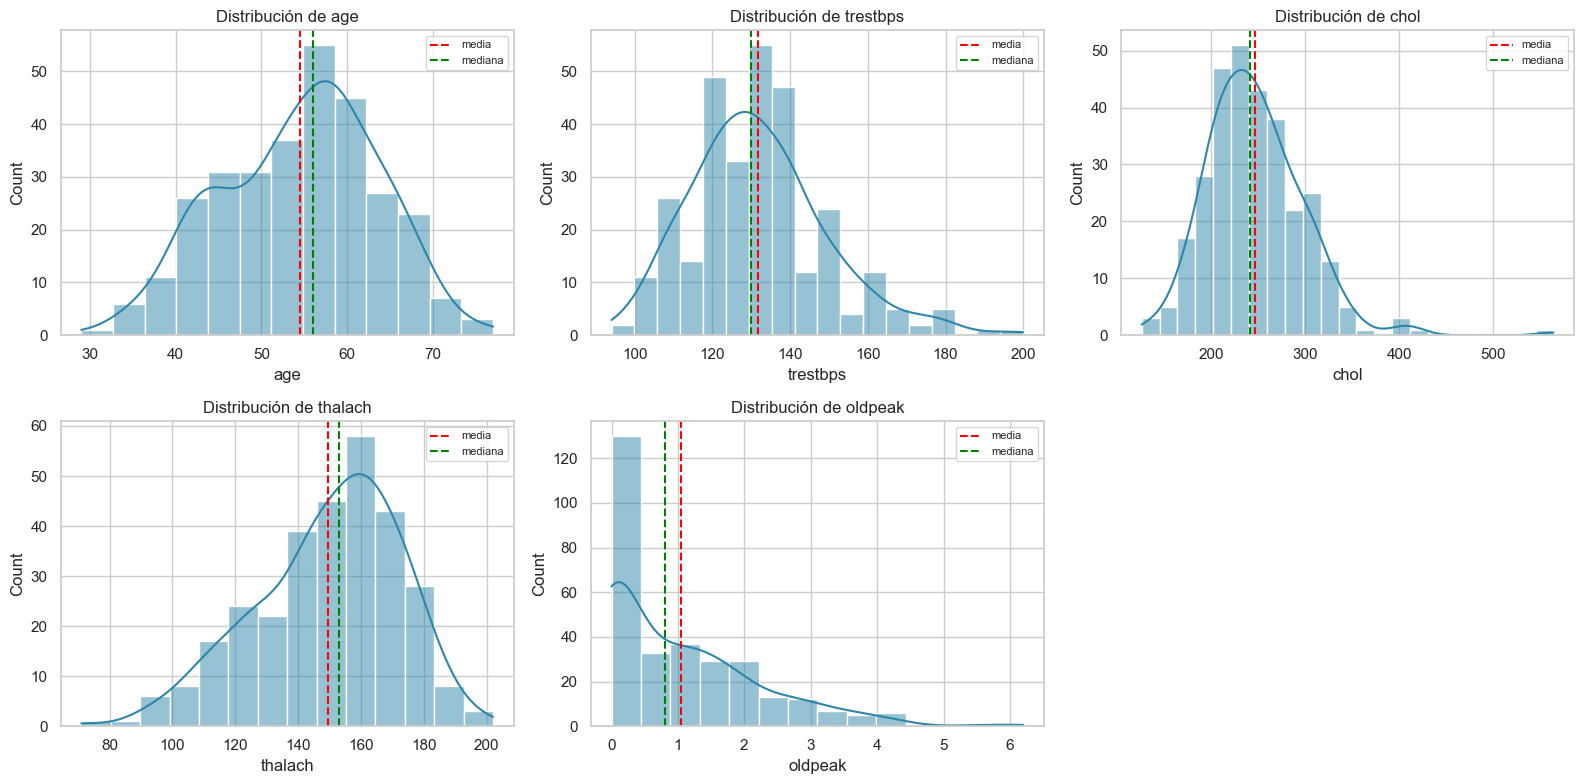

In [13]:
# =============================================================
# GRÁFICO 1 - Distribución de variables numéricas (histogramas)
# =============================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numericas):
    sns.histplot(df[col], kde=True, ax=axes[i], color="#2E86AB")
    axes[i].axvline(df[col].mean(), color="red", linestyle="--", label="media")
    axes[i].axvline(df[col].median(), color="green", linestyle="--", label="mediana")
    axes[i].set_title(f"Distribución de {col}")
    axes[i].legend(fontsize=8)

for j in range(len(numericas), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig("hist_numericas.png", dpi=150)
plt.show()

age (edad)
Distribución bastante simétrica, aunque con una leve cola hacia la izquierda (hacia edades menores). La media y la mediana están muy próximas, alrededor de los 55-56 años, podria decirse que la distribución es aproxidamdamente normal (media ≈ mediana ≈ moda). La mayoría de los pacientes se concentra entre 45 y 65 años, con pocos casos por debajo de 35 o por encima de 70.

trestbps (presión arterial en reposo)
Asimetría positiva moderada: la cola derecha es más larga, con algunos pacientes llegando a 180-200 mm Hg. La media queda levemente a la derecha de la mediana, señal de una cola pesada hacia valores altos. El grueso de los datos se concentra entre 120 y 140 mm Hg, un rango clínicamente esperable para presión en reposo.

chol (colesterol sérico)
Asimetría positiva bastante marcada, con una cola derecha larga y algunos outliers claros cerca de 400-560 mg/dl, bastante alejados del resto de la masa de datos (que se concentra entre 200 y 300. Esta variable tiene mediana < media porque unos pocos valores extremos "tiran" la media hacia la derecha.

thalach (frecuencia cardíaca máxima alcanzada)
Asimetría negativa (leve cola hacia la izquierda), al revés que las anteriores. La mayoría de los pacientes alcanza entre 140 y 180 latidos por minuto, con una cola de valores bajos (por debajo de 100, deportitas?) menos frecuente pero presente. Media y mediana están cerca, con la mediana levemente por encima de la media, coherente con esa cola izquierda.

oldpeak (depresión del segmento ST inducida por ejercicio)
La más asimétrica de las cinco, con diferencia. Hay una concentración enorme en 0 (más de 120 pacientes sin depresión del ST), y después la frecuencia cae abruptamente con una cola larga hacia la derecha hasta valores de 5-6. Acá la brecha entre media (~1) y mediana (~0.8) es chica en términos absolutos, pero la forma general es la más alejada de una distribución "normal" del grupo. 

chol y oldpeak son los casos más claros de asimetría positiva (con outliers hacia la derecha), mientras que age es la más cercana a la simetría. 

Esto puede ser cotejado con los valores de Asimetría de Estadistica descriptiva - variables numéricas



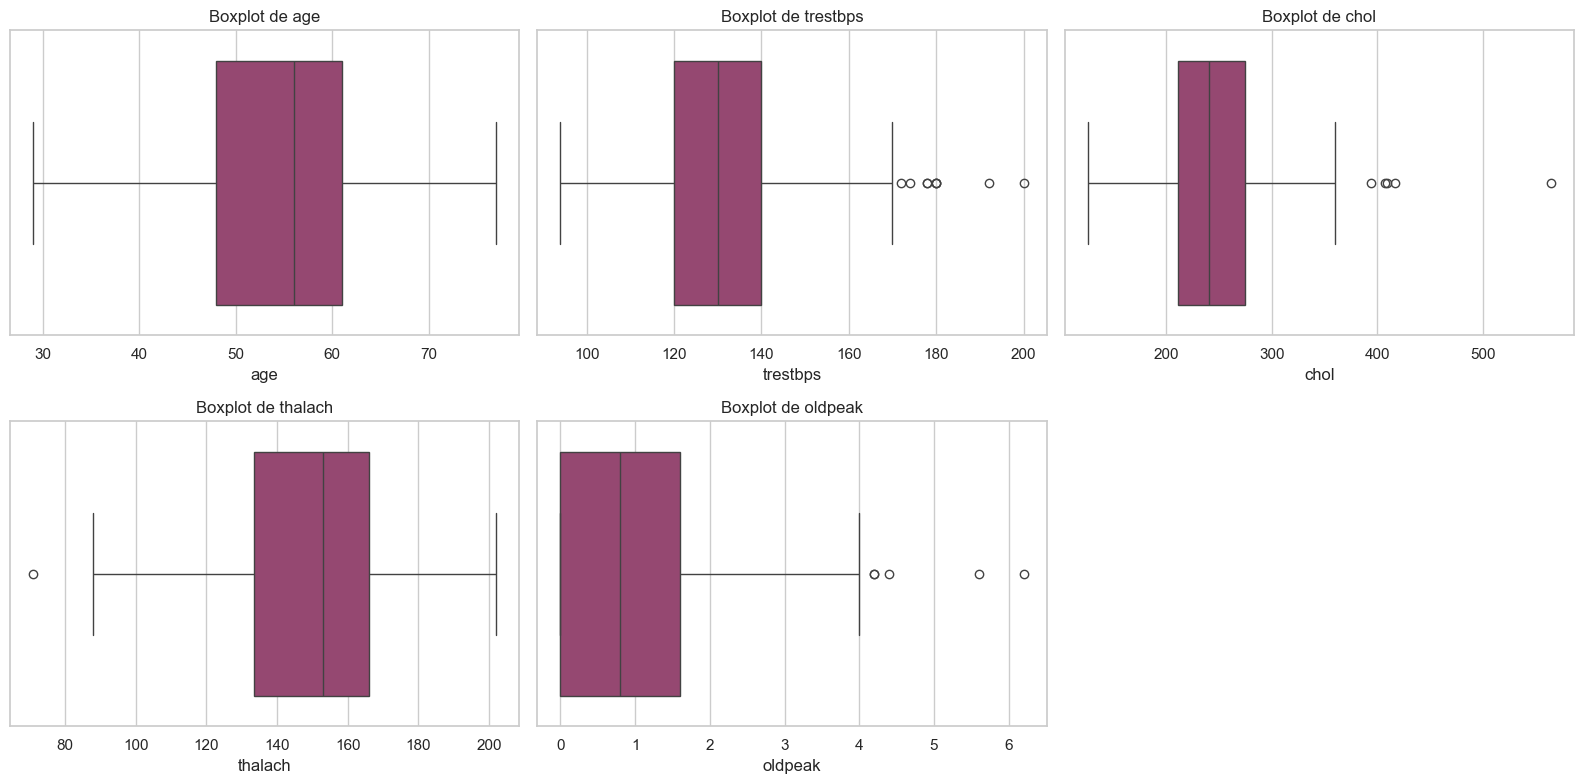

In [14]:
# ============================================
# GRÁFICO 2 - Boxplots (outliers y dispersión)
# ============================================
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numericas):
    sns.boxplot(x=df[col], ax=axes[i], color="#A23B72")
    axes[i].set_title(f"Boxplot de {col}")

for j in range(len(numericas), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig("boxplots_numericas.png", dpi=150)
plt.show()

age (edad)
Sin outliers. El rango intercuartílico (la caja) va aproximadamente de 48 a 61 años, con la mediana cerca de 56. Los bigotes son relativamente simétricos respecto a la caja, coherente con el coeficiente de asimetría casi nulo (-0.209), sin valores atípicos que llamen la atención.

trestbps (presión arterial en reposo)
Varios outliers del lado derecho (valores por encima de ~170 mm Hg, con dos casos cerca de 200). El bigote derecho es más corto que la distancia a esos outliers, esos pacientes con presión muy alta superan 1.5×IQR desde Q3 y quedan como dato atipico. Coincide con la asimetría positiva moderada (0.706).

chol (colesterol)
varios outliers agrupados alrededor de 400-420, y uno bastante aislado cerca de 560-570, claramente separado del resto de la nube de puntos. Este último es un caso extremo que valdría la pena revisar puntualmente (podría ser un dato real de un paciente con colesterol muy alto, o un posible error de carga). Es el que más se destaca del set, consistente con tener la asimetría más alta junto con oldpeak (1.136).

thalach (frecuencia cardíaca máxima)
El outlier está del lado izquierdo (un paciente con frecuencia cardíaca máxima muy baja, cerca de 70). Esto es coherente con la asimetría negativa (-0.537).La cola "pesada" de esta variable va hacia valores bajos, no altos.

oldpeak (depresión del ST)
Es el boxplot con la caja más "pegada" al piso: la mediana está muy cerca de 0-1, y hay varios outliers del lado derecho, dos de ellos bastante alejados cerca de 5.5-6. Esto se explica por lo observado en el histograma: la enorme concentración de pacientes en valores cercanos a 0 hace que cualquier valor alto quede marcado como atípico, aunque en términos clínicos esos valores altos sean justamente los más relevantes (mayor depresión del ST = mayor isquemia).

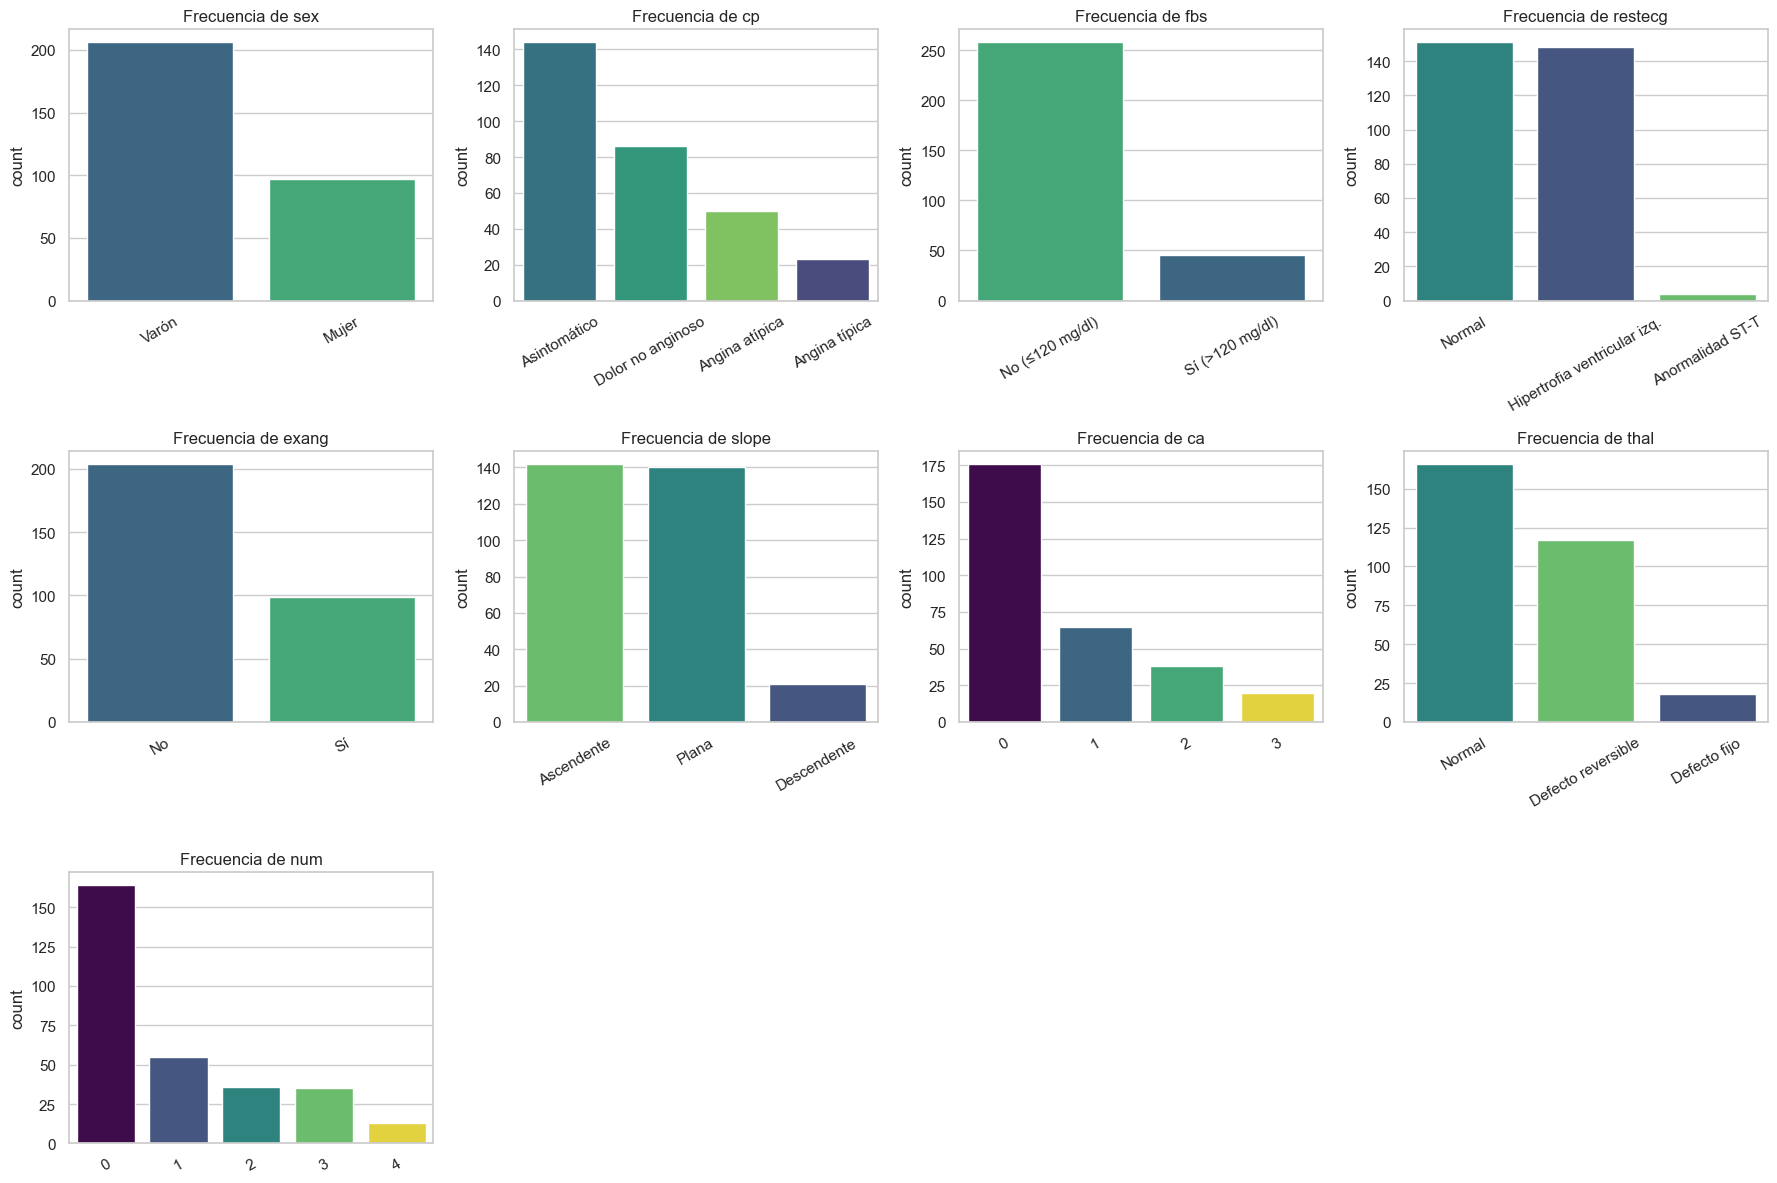

In [15]:
# =================================================
# GRÁFICO 3 - Distribución de variables categóricas
# =================================================
import math

# Usamos la versión con etiqueta si existe, sino la columna original
columnas_a_graficar = [
    f"{col}_label" if f"{col}_label" in df.columns else col
    for col in categoricas
]

n_cols_grid = 4
n_filas_grid = math.ceil(len(columnas_a_graficar) / n_cols_grid)

fig, axes = plt.subplots(n_filas_grid, n_cols_grid, figsize=(18, 4 * n_filas_grid))
axes = axes.flatten()

for i, col in enumerate(columnas_a_graficar):
    sns.countplot(
        x=df[col],
        ax=axes[i],
        hue=df[col],
        palette="viridis",
        legend=False,
        order=df[col].value_counts().index  # ordena de mayor a menor frecuencia
    )
    axes[i].set_title(f"Frecuencia de {col.replace('_label', '')}")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=30)

for j in range(len(columnas_a_graficar), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig("countplots_categoricas.png", dpi=150)
plt.show()

sex 
Más del doble de varones (~206) que mujeres (~97) en la muestra. Coherente con la entropía relativamente alta (0.905/1.000) — el desbalance existe pero no es extremo.

cp (tipo de dolor de pecho) 
"Asintomático" es ampliamente la categoría más frecuente (~144 casos), seguida por "Dolor no anginoso" (~86), y con "Angina atípica" y "Angina típica" mucho menos representadas. Clinicamente la mayoría de los pacientes de este dataset no reporta dolor de pecho clásico "asintomático" no siempre significa "sano".

fbs (glucemia en ayunas) 
El más desbalanceado de todo el set, tal como anticipaba su entropía baja (0.606/1.000): la gran mayoría (~258) tiene azúcar normal, y solo un grupo chico (~45) supera 120 mg/dl.

restecg (resultado del electrocardiograma en reposo)
"Normal" e "Hipertrofia ventricular izq." están casi empatados (~148 y ~146), mientras que "Anormalidad ST-T" es prácticamente anecdótica (apenas unos pocos casos). Esto explica la entropía intermedia (0.687 de ratio) — hay dos categorías grandes bien balanceadas entre sí, pero una tercera casi vacía que "tira hacia abajo" el equilibrio general.

exang (angina inducida por ejercicio) 
Mayoría no presenta angina con el ejercicio (~204 "No" vs ~99 "Sí"), un desbalance moderado.

slope (pendiente del segmento ST en el pico del ejercicio) 
"Ascendente" y "Plana" están casi empatadas (~142 y ~140), con "Descendente" mucho menos frecuente (~21). Esto muestra por qué su entropía (0.816 de ratio) fue de las más altas entre las de 3 categorías: dos clases dominan de forma pareja.

ca (vasos coloreados por fluoroscopía) 
Fuertemente concentrada en 0 (~176 casos, la mitad del dataset), decreciendo progresivamente hacia 1, 2 y 3. Tiene sentido clínico: la mayoría de los pacientes no muestra vasos obstruidos visibles.

thal (resultado de la prueba de perfusión miocárdica con talio)
"Normal" domina (~166), seguida por "Defecto reversible" (~117), con "Defecto fijo" bastante menos frecuente (~18).

num (diagnóstico, variable objetivo)
La categoría 0 ("sin enfermedad") es la más numerosa (~164), y a partir de ahí las frecuencias decrecen con la severidad: 1 (~55), 2 (~36), 3 (~35), 4 (~13). Es el patrón esperable en un dataset de diagnóstico: hay más casos sanos que enfermos, y dentro de los enfermos, los grados más severos son los menos frecuentes, ›la "cola" de severidad se va angostando.

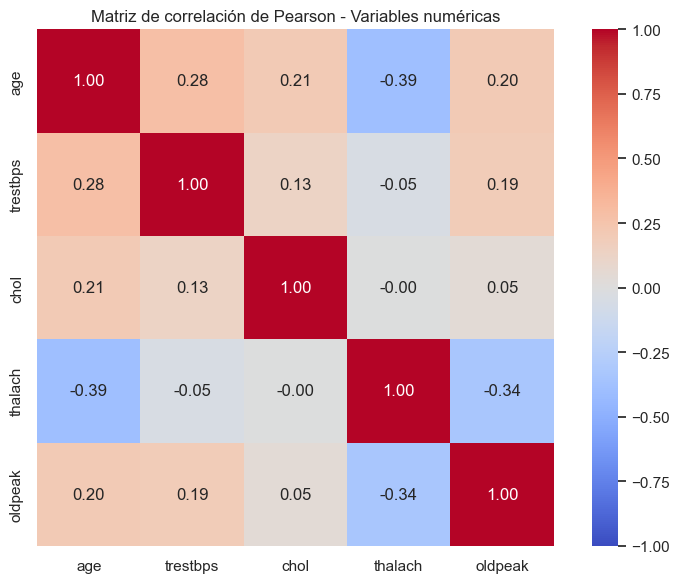

In [16]:
# ============================================
# GRÁFICO 4 - Matriz de correlación (numéricas)
# ============================================
plt.figure(figsize=(8, 6))
corr = df[numericas].corr(method="pearson")
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Matriz de correlación de Pearson - Variables numéricas")
plt.tight_layout()
plt.savefig("matriz_correlacion.png", dpi=150)
plt.show()

Correlaciones débiles a moderadas en general, sin ninguna relación fuerte (todas por debajo de 0.4 en valor absoluto).
Pearson mide relación lineal y es sensible a esos extremos, así que para confirmar si hay una relación monótona más fuerte que lo que muestra Pearson, convendría correr también Spearman sobre estas mismas variables.

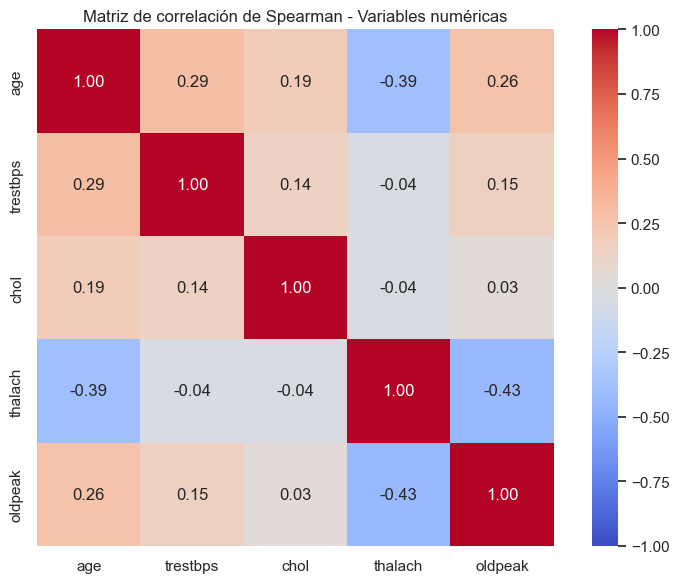

In [17]:
# ============================================
# GRÁFICO 4b - Matriz de correlación de Spearman (numéricas)
# ============================================
plt.figure(figsize=(8, 6))
corr_spearman = df[numericas].corr(method="spearman")
sns.heatmap(corr_spearman, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Matriz de correlación de Spearman - Variables numéricas")
plt.tight_layout()
plt.savefig("matriz_correlacion_spearman.png", dpi=150)
plt.show()

las correlaciones siguien siendo debiles. 

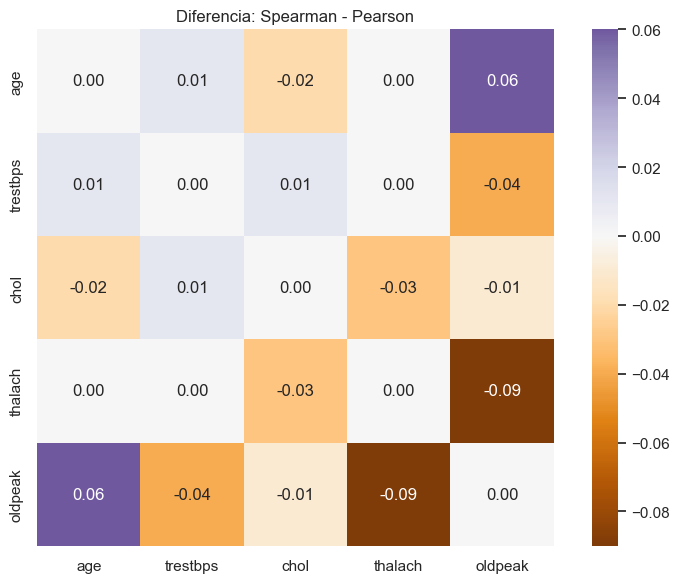

In [18]:
# ============================================
# GRÁFICO 4c - Diferencia entre Pearson y Spearman
# ============================================
corr_pearson = df[numericas].corr(method="pearson")
corr_spearman = df[numericas].corr(method="spearman")
diferencia = (corr_spearman - corr_pearson).round(2)

plt.figure(figsize=(8, 6))
sns.heatmap(diferencia, annot=True, fmt=".2f", cmap="PuOr", center=0, square=True)
plt.title("Diferencia: Spearman - Pearson")
plt.tight_layout()
plt.savefig("diferencia_correlaciones.png", dpi=150)
plt.show()

Spearman confirma el mismo panorama sin agregar información sustancialmente distinta.

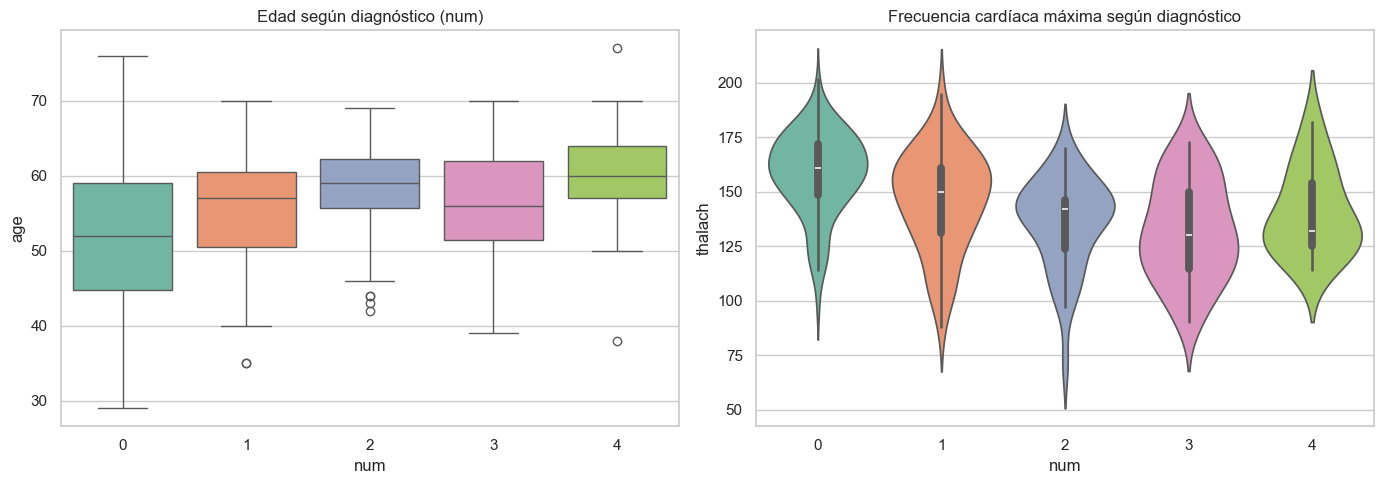

In [19]:
# ========================================================================
#  GRÁFICO 5 - Relación numérica-categórica
#  Frecuencia cardiaca max y edad según diagnóstico "num"(vasos afectados)
# =========================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="num", y="age", ax=axes[0], palette="Set2", hue="num", legend=False)
axes[0].set_title("Edad según diagnóstico (num)")

sns.violinplot(data=df, x="num", y="thalach", ax=axes[1], palette="Set2", hue="num", legend=False)
axes[1].set_title("Frecuencia cardíaca máxima según diagnóstico")

plt.tight_layout()
plt.savefig("relacion_numerica_categorica.png", dpi=150)
plt.show()

Edad según diagnóstico: los pacientes sin enfermedad (num=0) son en promedio más jóvenes (mediana ~52 años) que los que sí tienen algún grado de diagnóstico. A partir de num=1 en adelante, las medianas suben y quedan relativamente parecidas entre sí (entre 56 y 60 años), sin una tendencia perfectamente creciente con la severidad — el grupo 2 tiene la mediana más alta (~59), pero también acumula varios outliers hacia edades bajas (~40-45). Podemos decir que tener enfermedad se asocia a mayor edad, pero el grado de severidad no parece escalar linealmente con la edad. 

Frecuencia cardíaca máxima según diagnóstico: A medida que aumenta la severidad del diagnóstico (num de 0 a 3), la mediana de thalach baja progresivamente (de ~160 en sanos a ~130 en num=3), y los violines se van corriendo hacia valores más bajos. Esto confirma numéricamente algo esperable clínicamente: a mayor severidad de enfermedad coronaria, menor capacidad de alcanzar frecuencias cardíacas altas durante el esfuerzo. El grupo num=4 rompe un poco la tendencia (sube levemente respecto a num=3), aunque tiene pocos casos (~13, como vimos en el countplot), por lo que su forma es menos confiable estadísticamente.

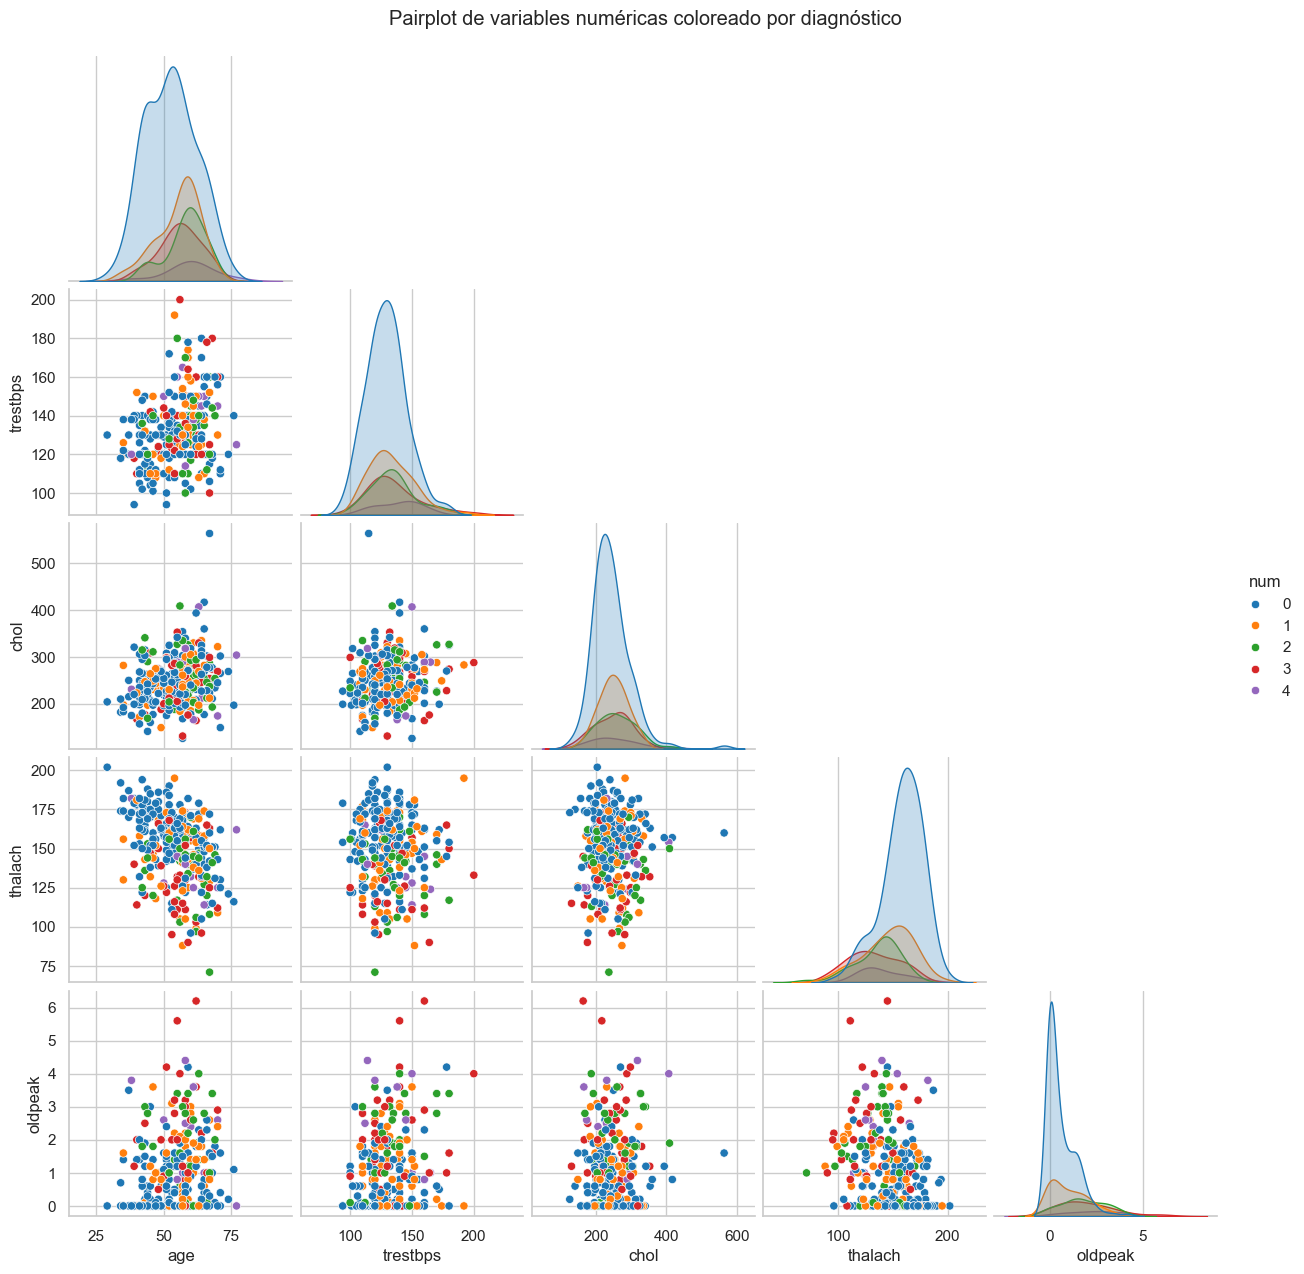

In [20]:
# ==============================================================
# GRÁFICO 6 - Pairplot multivariado (numéricas + num categórico)
# ==============================================================
g = sns.pairplot(df, vars=numericas, hue="num", corner=True, palette="tab10")
g.fig.suptitle("Pairplot de variables numéricas coloreado por diagnóstico", y=1.02)
g.savefig("pairplot.png", dpi=200, bbox_inches="tight")
plt.show()

thalach vs oldpeak (Frecuencia cardíaca máxima alcanzada durante la prueba de esfuerzo vs Depresión del segmento ST inducida por el ejercicio) acá se nota lo más interesante del pairplot — los puntos rojos (num=3) y morados (num=4) tienden a concentrarse en la zona de thalach bajo y oldpeak alto (esquina inferior derecha de ese panel), mientras que los azules (num=0) dominan la zona de thalach alto y oldpeak bajo (esquina superior izquierda). Es la combinación de variables que mejor separa visualmente los diagnósticos severos de los casos sanos.

num         0   1   2   3   4
sex_label                    
Mujer      72   9   7   7   2
Varón      92  46  29  28  11


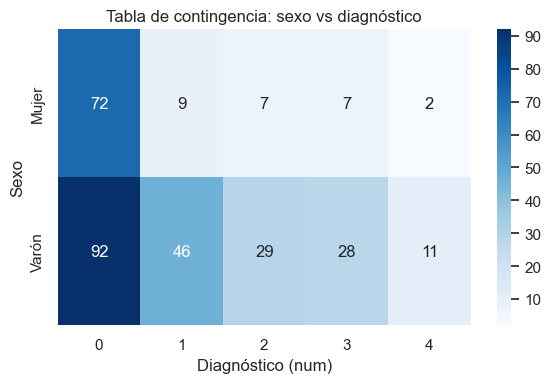

In [21]:
# ========================================================================
# GRÁFICO 7 - Relación entre variables categóricas (tabla de contingencia)
# ========================================================================
tabla_contingencia = pd.crosstab(df["sex_label"], df["num"])
print(tabla_contingencia)

plt.figure(figsize=(6, 4))
sns.heatmap(tabla_contingencia, annot=True, fmt="d", cmap="Blues")
plt.title("Tabla de contingencia: sexo vs diagnóstico")
plt.xlabel("Diagnóstico (num)")
plt.ylabel("Sexo")
plt.tight_layout()
plt.savefig("crosstab_sexo_diagnostico.png", dpi=150)
plt.show()

En mujeres (97 en total), la enorme mayoría (72, ~74%) no presenta enfermedad diagnosticada (num=0), y los pocos casos restantes se reparten de forma bastante pareja y baja entre los grados 1 a 4 (entre 2 y 9 casos cada uno). En varones (206 en total) el panorama es distinto: aunque num=0 sigue siendo la categoría más frecuente (92 casos), representa menos de la mitad del grupo (~45%), y hay una cantidad considerable de varones con diagnóstico positivo en todos los grados de severidad —particularmente 46 casos en num=1 y 29 en num=2—, muy por encima de lo que se ve en mujeres. En términos relativos, esto sugiere que la proporción de varones con enfermedad cardíaca diagnosticada en esta muestra es notablemente mayor que la de mujeres, un patrón consistente con la literatura epidemiológica que asocia el sexo masculino a mayor riesgo cardiovascular, aunque conviene recordar que la muestra tiene más del doble de varones que de mujeres, así que las diferencias en conteos absolutos hay que leerlas junto con esa base desigual.

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, HTML
import os
import webbrowser

# Generar pairplot con Seaborn (alta calidad visual)
g = sns.pairplot(
    df,
    hue="num",
    corner=True,
    height=2.5,
    plot_kws={
        "alpha": 0.7,
        "s": 35
    }
)

# Ajustar diseño
g.fig.suptitle(
    "Pairplot interactivo",
    y=1.02,
    fontsize=18
)

# Guardar en alta resolución
imagen = "pairplot.png"

g.savefig(
    imagen,
    dpi=300,
    bbox_inches="tight"
)

plt.close()


# Crear HTML pantalla completa
html = f"""
<!DOCTYPE html>
<html>
<head>
<meta charset="utf-8">

<title>Pairplot</title>

<style>

html, body {{
    margin: 0;
    padding: 0;
    width: 100%;
    height: 100%;
    background: white;
    overflow: hidden;
}}

.container {{
    width: 100vw;
    height: 100vh;
    display: flex;
    justify-content: center;
    align-items: center;
}}

img {{
    max-width: 100%;
    max-height: 100%;
    object-fit: contain;
}}

</style>

</head>

<body>

<div class="container">
    <img src="{imagen}">
</div>

</body>

</html>
"""


# Guardar HTML
archivo_html = "pairplot.html"

with open(
    archivo_html,
    "w",
    encoding="utf-8"
) as f:
    f.write(html)


# Abrir automáticamente en navegador
webbrowser.open(
    "file://" + os.path.abspath(archivo_html)
)

True